In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys, json, gc, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import math

warnings.filterwarnings('ignore')

In [20]:
# Paths
BASE_DIR = "/scratch/michele.calabro/gears/VCC/SPECTRA"

DATASET_SIZE = "5k"
RUNS = list(range(10)) #TODO: for now just one run for testing
MODELS = ["SPECTRA", "baseline", "scLambda", "GEARS"]
MODEL_DIR = f"{BASE_DIR}/results/final_vcc"
GT_PATH = f"{MODEL_DIR}/test_cells_vcc.h5ad"

# Define where to save/load our cache
CACHE_FILE = f"{BASE_DIR}/benchmark/results/benchmark_cell_eval_cache_{DATASET_SIZE}.csv"
RESULTS_CSV = f"{BASE_DIR}/benchmark/results/full_comparison_cell_eval_{DATASET_SIZE}.csv"
os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)

# plots
PLOTS_FOLDER = f"{BASE_DIR}/benchmark/results/plots"
os.makedirs(PLOTS_FOLDER, exist_ok=True)

In [21]:
def get_h5ad_path(model, run_id):
    '''
    returns path of h5ad
    '''
    base = MODEL_DIR
    return f"{base}/pred_adata-{model}-{run_id}.h5ad"

In [22]:
# Load control cells
print("Loading control cells for DES calculation...")
base_adata = sc.read_h5ad(f"{MODEL_DIR}/control_test_cells_vcc.h5ad")
CTRL_CELLS = base_adata[base_adata.obs['target_gene'] == 'non-targeting']
CTRL_CELLS.X = CTRL_CELLS.X.toarray() if sp.issparse(CTRL_CELLS.X) else CTRL_CELLS.X
del base_adata

print(f"Extracted {len(CTRL_CELLS)} control cells.")

Loading control cells for DES calculation...
Extracted 5160 control cells.


In [23]:
from cell_eval import MetricsEvaluator

def evaluate_single_run(model, run_id, gt_path):

    pred_path = get_h5ad_path(model, run_id)
    row = {"Model": model, "Run": run_id}
    
    if not os.path.exists(pred_path):
        raise ValueError(f"file at {pred_path} does not exists")
    if not os.path.exists(gt_path):
        raise ValueError(f"file at {gt_path} does not exists")

    adata_pred = sc.read_h5ad(pred_path)
    adata_true = sc.read_h5ad(gt_path)

    assert set(adata_true.obs['target_gene'].unique())== set(adata_pred.obs['target_gene'].unique()), "perturbations not matching"
    
    # adata_true.obs['target_gene'] = adata_true.obs['target_gene'].astype('category')
    # adata_pred.obs['target_gene'] = adata_pred.obs['target_gene'].astype('category')
    adata_true = sc.concat([adata_true, CTRL_CELLS], join='inner')
    adata_pred = sc.concat([adata_pred, CTRL_CELLS], join='inner')

    evaluator = MetricsEvaluator(
        adata_pred=adata_pred,
        adata_real=adata_true,
        control_pert="non-targeting",
        pert_col="target_gene",
        num_threads=64,
    )
    agg_results = evaluator.compute()[1]
    mask = agg_results["statistic"] == "mean"
    agg_results = agg_results.filter(mask).drop('statistic')
    row_dict = agg_results.row(0, named=True) 
    row.update(row_dict)
    
    row["Status"] = "OK"
    
    del adata_true, adata_pred
    gc.collect()
            
    return row

In [24]:
import concurrent.futures

TOP_DEGS = None

cached_results = []
tasks_to_run = []
if os.path.exists(CACHE_FILE):
    df_cache = pd.read_csv(CACHE_FILE)
    print(f"📦 Found existing cache with {len(df_cache)} records at:\n   {CACHE_FILE}")
else:
    df_cache = pd.DataFrame()
    print("📦 No existing cache found. Starting fresh.")

# Filter Tasks (Only run what is missing or previously failed)
for m in MODELS:
    for r in RUNS:
        # Check if this exact run is already in the cache AND succeeded
        if not df_cache.empty:
            mask = (
                (df_cache['Model'] == m) & 
                (df_cache['Run'] == r) & 
                (df_cache['Status'] == 'OK')
            ) # mask is a boolean pandas Series (true/false for each row of df_cache)
            if mask.any():
                # It's already done! Add it to our completed pile.
                cached_results.append(df_cache[mask].iloc[0].to_dict())
                continue
        
        # If not found or not 'OK', add it to the compute queue
        tasks_to_run.append((m, r))

# Define the Worker
def parallel_worker(model, run_id):
    """Worker function executed by each CPU core."""
    old_stdout, old_stderr = sys.stdout, sys.stderr
    with open(os.devnull, 'w') as devnull:
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            result = evaluate_single_run(model, run_id, gt_path=GT_PATH)
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr
    return result

# Execute Missing Tasks using concurrent.futures
new_results = []
if tasks_to_run:
    print(f"\n🚀 Running {len(tasks_to_run)} missing tasks on 16 CPUs...")
    
    # Initialize the Process Pool
    with concurrent.futures.ProcessPoolExecutor(max_workers=16) as executor:
        # Submit all tasks to the executor
        futures = [executor.submit(parallel_worker, m, r) for m, r in tasks_to_run]
        
        # Wrap as_completed with tqdm to keep the progress bar updated
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks_to_run), desc="Evaluating Runs"):
            new_results.append(future.result())
else:
    print("\n✅ All tasks are already cached! Skipping heavy computation.")

# 5. Compile, Save, and Output
all_results = cached_results + new_results
df = pd.DataFrame(all_results)

if not df.empty:
    
    # Save the updated cache to disk
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    df.to_csv(CACHE_FILE, index=False)
    print(f"\n💾 Master cache updated and saved!")
    
    display(df.head())
else:
    print("\n[!] DataFrame is empty. All workers failed.")

📦 Found existing cache with 20 records at:
   /scratch/michele.calabro/gears/VCC/SPECTRA/benchmark/results/benchmark_cell_eval_cache_5k.csv

🚀 Running 20 missing tasks on 16 CPUs...


Evaluating Runs:   0%|          | 0/20 [00:00<?, ?it/s]WARNING:cell_eval._evaluator:Output directory ./cell-eval-outdir already exists, potential overwrite occurring
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 4.55])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 4.55])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 4.55])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 4.55])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (


💾 Master cache updated and saved!


,Model,Run,overlap_at_N,overlap_at_50,overlap_at_100,overlap_at_200,overlap_at_500,precision_at_N,precision_at_50,precision_at_100,...,mse,mae,mse_delta,mae_delta,discrimination_score_l1,discrimination_score_l2,discrimination_score_cosine,pearson_edistance,clustering_agreement,Status
0,SPECTRA,0,0.161104,0.032,0.046870,0.062407,0.085836,0.217555,0.032,0.0465,...,0.004425,0.037827,0.004425,0.037827,0.5525,0.6050,0.5075,0.014483,0.161978,OK
1,SPECTRA,1,0.160491,0.037,0.046685,0.065883,0.086467,0.218089,0.037,0.0470,...,0.004419,0.037845,0.004419,0.037845,0.5525,0.6075,0.5125,0.061872,0.034581,OK
2,SPECTRA,2,0.159256,0.038,0.048685,0.060270,0.085343,0.218065,0.038,0.0485,...,0.004429,0.037870,0.004429,0.037870,0.5550,0.6075,0.5150,0.044404,0.193259,OK
3,SPECTRA,3,0.160012,0.032,0.045185,0.058157,0.084991,0.217647,0.032,0.0450,...,0.004424,0.037828,0.004424,0.037828,0.5525,0.6050,0.5175,0.030176,0.000000,OK
4,SPECTRA,4,0.159723,0.024,0.046500,0.059280,0.084265,0.217691,0.024,0.0465,...,0.004422,0.037834,0.004422,0.037834,0.5550,0.6075,0.5225,-0.034412,0.202984,OK


In [25]:
CORE_METRICS = {
        "overlap_at_N": np.nan, 
        "overlap_at_50": np.nan, 
        "precision_at_N": np.nan, 
        "precision_at_50": np.nan, 
        "de_direction_match": np.nan, 
        "pr_auc": np.nan, 
        "roc_auc": np.nan, 
        "pearson_delta": np.nan, 
        "mae": np.nan, 
        "mse": np.nan, 
        "pearson_edistance": np.nan,
        "clustering_agreement": np.nan,
}

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# Summary Tables — Mean ± Std for each mdel
# ═══════════════════════════════════════════════════════════════════════

df_ok = df[df['Status'] == 'OK'].copy()

# Build publication table
rows = []
for model, g in df_ok.groupby(['Model']):
    row = {'Model': model, 'N': len(g)}
    for m in CORE_METRICS.keys():
        if m in g.columns:
            vals = g[m].dropna()
            row[f'{m}_mean'] = vals.mean()
            row[f'{m}_std'] = vals.std()
            row[f'{m}_str'] = f"{vals.mean():.4f} ± {vals.std():.4f}"
    rows.append(row)

df_summary = pd.DataFrame(rows)
    
display_cols = ['Model', 'N'] + [f'{m}_str' for m in CORE_METRICS.keys() if f'{m}_str' in df_summary.columns]
display_df = df_summary[display_cols].copy()
display_df.columns = ['Model', 'Runs'] + [m for m in CORE_METRICS.keys() if f'{m}_str' in df_summary.columns]
display(display_df.set_index('Model'))

,Runs,overlap_at_N,overlap_at_50,precision_at_N,precision_at_50,de_direction_match,pr_auc,roc_auc,pearson_delta,mae,mse,pearson_edistance,clustering_agreement
Model,,,,,,,,,,,,,
"(GEARS,)",10,0.1554 ± 0.0017,0.0413 ± 0.0052,0.1731 ± 0.0009,0.0413 ± 0.0052,0.5806 ± 0.0063,0.1933 ± 0.0004,0.4396 ± 0.0007,0.0973 ± 0.0067,0.0210 ± 0.0001,0.0029 ± 0.0000,0.5720 ± 0.0137,0.0224 ± 0.0297
"(SPECTRA,)",10,0.1601 ± 0.0010,0.0312 ± 0.0047,0.2179 ± 0.0002,0.0312 ± 0.0047,0.5520 ± 0.0010,0.2240 ± 0.0003,0.5027 ± 0.0006,0.1735 ± 0.0007,0.0378 ± 0.0000,0.0044 ± 0.0000,0.0170 ± 0.0345,0.1274 ± 0.0993
"(baseline,)",10,0.1806 ± 0.0000,0.0790 ± 0.0000,0.1985 ± 0.0000,0.0790 ± 0.0000,0.6667 ± 0.0000,0.1982 ± 0.0000,0.4475 ± 0.0000,0.2247 ± 0.0000,0.0201 ± 0.0000,0.0028 ± 0.0000,0.0638 ± 0.0000,0.0000 ± 0.0000
"(scLambda,)",10,0.1666 ± 0.0010,0.0482 ± 0.0012,0.1943 ± 0.0004,0.0482 ± 0.0012,0.6171 ± 0.0037,0.1962 ± 0.0003,0.4423 ± 0.0008,0.1330 ± 0.0054,0.0214 ± 0.0000,0.0029 ± 0.0000,0.1904 ± 0.2596,0.1693 ± 0.0346


In [27]:
cmap = plt.cm.viridis  # you can choose others: plasma, coolwarm, etc.
colors = cmap(np.linspace(0, 1, len(MODELS)))
PALETTE = {
    model: plt.matplotlib.colors.to_hex(color)
    for model, color in zip(MODELS, colors)
}

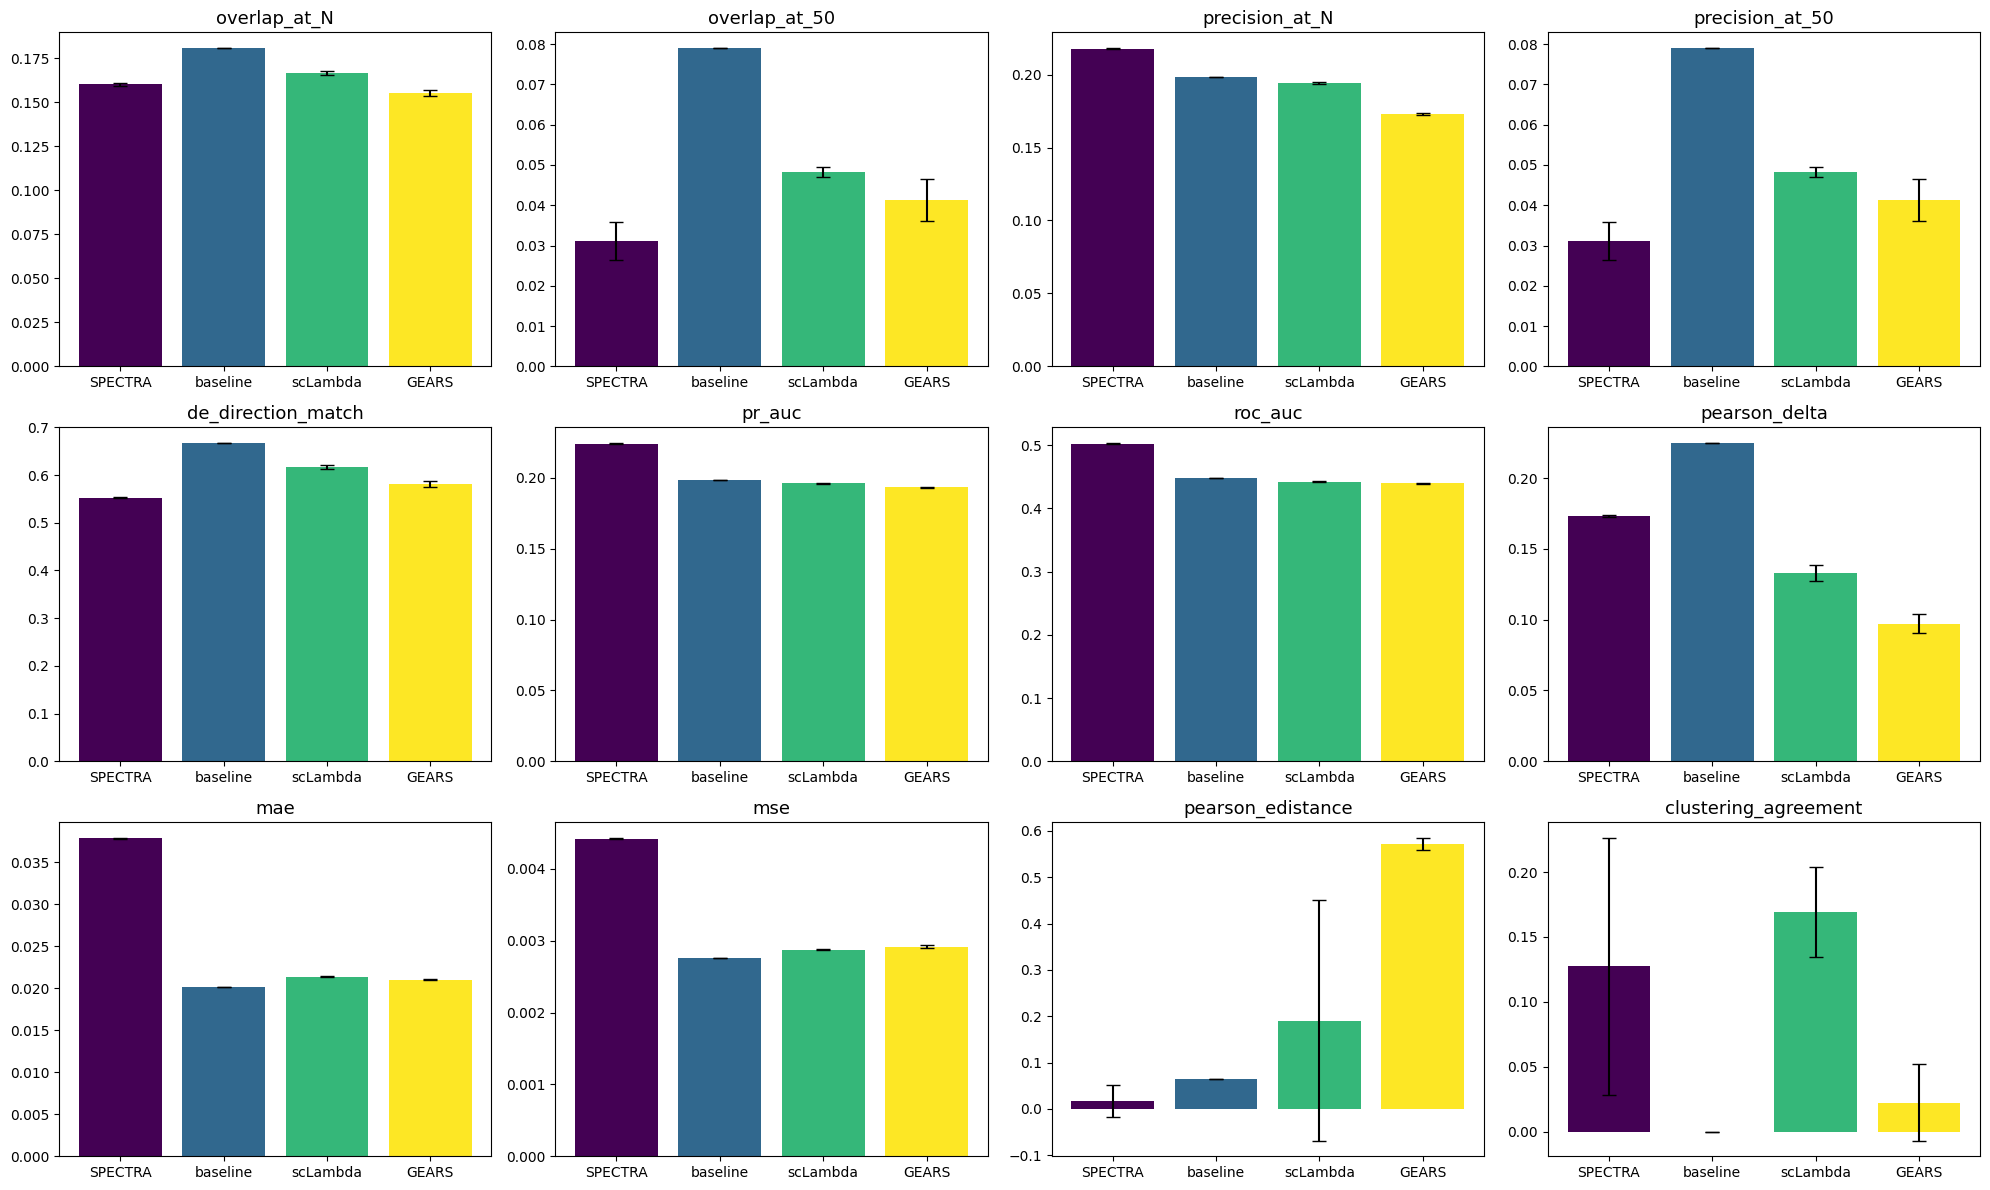

In [30]:
key_metrics = CORE_METRICS.keys()

# Set up the figure for this specific scenario
n_metrics = len(key_metrics)
ncols = math.ceil(n_metrics / 3)
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]


for ax, metric in zip(axes, key_metrics):
    # Filter for valid data within this scenario
    data = df[df[metric].notna() & (df['Status'] == 'OK')]
    if len(data) == 0: continue
    
    means = data.groupby('Model')[metric].mean().reindex(MODELS)
    stds = data.groupby('Model')[metric].std().reindex(MODELS)
    
    bars = ax.bar(MODELS, means, yerr=stds, capsize=5, color=[PALETTE[m] for m in MODELS], edgecolor='none', linewidth=0.8)
    
    # # Add value labels on bars
    # for bar, mean, std in zip(bars, means, stds):
    #     # Skip if the mean is NaN (e.g. model didn't complete this scenario)
    #     if pd.isna(mean): continue 
    #     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
    #             f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_title(f'{metric}', fontsize=13) #fontweight='bold'
    #ax.set_ylabel('Score')

# Add a Scenario-specific Super Title
#plt.suptitle(f'Key Metrics — {DATASET_SIZE} VCC Benchmark', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{PLOTS_FOLDER}/benchmark_mean_perfromances_cell_eval.pdf')
plt.show()

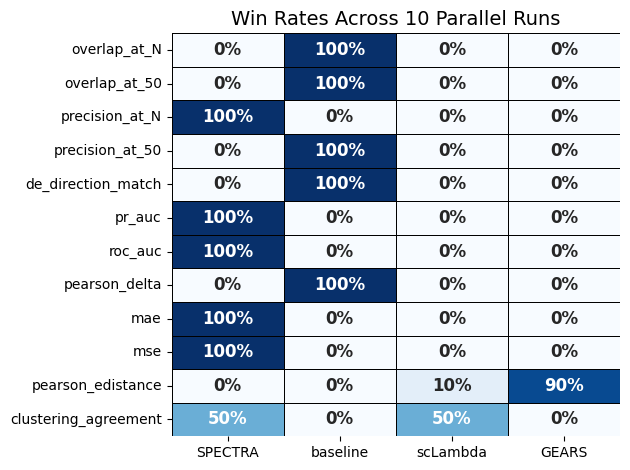

In [31]:
# ───────────────────────────────────────────────────────────────────────
# PLOT 2: The "Win-Rate" Head-to-Head Heatmap
# ───────────────────────────────────────────────────────────────────────
# Calculate: For each (Scenario, Run), who got 1st place?
win_records = []

for run in df_ok['Run'].unique():
    run_data = df_ok[df_ok['Run'] == run]
    
    # We need all models to be present to fairly judge a "win"
    if len(run_data['Model'].unique()) < len(MODELS): continue

    for metric in key_metrics:
        if run_data[metric].isna().all(): continue

        direction = 'Lower' if metric in ['WMSE', 'MSE', 'Wasserstein_distance'] else 'Higher'
        if direction == 'Lower':
            winner = run_data.loc[run_data[metric].idxmin()]['Model']
        else:
            winner = run_data.loc[run_data[metric].idxmax()]['Model']
            
        win_records.append({'Run': run, 'Metric': metric, 'Winner': winner})

wins_df = pd.DataFrame(win_records)

if not wins_df.empty:
        
    # Calculate Win Percentage
    win_counts = wins_df.groupby(['Metric', 'Winner']).size().unstack(fill_value=0)
    
    # Ensure all models are columns even if they won 0 times
    for m in MODELS:
        if m not in win_counts: win_counts[m] = 0
            
    win_pct = (win_counts.div(win_counts.sum(axis=1), axis=0) * 100).fillna(0)
    
    # Reorder metrics and models for consistency
    win_pct = win_pct.reindex([m for m in key_metrics]).reindex(columns=MODELS).fillna(0)
    
    ax=sns.heatmap(
        win_pct, annot=True, fmt=".0f", cmap="Blues", cbar=False,
        linewidths=0.5, linecolor='black', annot_kws={"size": 12, "weight": "bold"}
    )
    
    plt.title(f"Win Rates Across 10 Parallel Runs", fontsize=14)
    plt.ylabel('')
    plt.xlabel('')
    
    # Add % sign to annotations
    for t in ax.texts: t.set_text(t.get_text() + "%")

    plt.tight_layout()
    plt.savefig(f'{PLOTS_FOLDER}/win_rates_cell_eval.pdf')
    plt.show()
else:
    print("Could not compute win-rates (make sure all models completed the same runs).")